# `ConstantScheduler`

This notebook provides an empirical demonstration of the expected behavior of a `ConstantScheduler`. Its purpose is to make the module's scheduling behavior observable in a simple setting in which it can be studied in isolation, rather than to exhaustively validate every implementation detail.

The capability examined is constant scheduling across depth. A `ConstantScheduler` returns the same configured value regardless of the depth at which it is evaluated.

## Conceptual Overview

A `ConstantScheduler` defines the simplest possible relationship between depth and scheduled value. For a configured value $v$, the value returned at depth $d$ is

$$
S(d)=v.
$$

Depth therefore has no influence on the result: evaluating the scheduler at different depths always produces the same configured value.

### Scope of the demonstration

The experiment evaluates a `ConstantScheduler` over a finite range of depths and visualizes the resulting schedule.

In [1]:
import matplotlib.pyplot as plt

from jacinta.utils.schedulers import ConstantScheduler

## Configuration

The parameters below are chosen to make the relevant behavior visible, but they should not be interpreted as general-purpose defaults.

`VALUE = 500` defines the constant value returned by the scheduler at every depth.

`MAX_DEPTH = 10000` determines the range over which the schedule is visualized. It does not affect the scheduler itself.

In [2]:
# hyperparameters
VALUE = 500

# plot parameters
MAX_DEPTH = 10000

## Visualization Utilities

The `ConstantScheduler` can be evaluated directly at a requested depth. The following helper exposes that mapping for visualization.

`plot_scheduler()` evaluates the scheduler at every depth from zero through `MAX_DEPTH` and plots the resulting schedule. This provides a direct view of its behavior across the displayed range.

In [3]:
def plot_scheduler(
    ax: plt.Axes,
    scheduler: ConstantScheduler,
) -> None:
    """
    Plot a scheduler.

    Args:
        ax (plt.Axes): The axes to plot on.
        scheduler (ConstantScheduler): The scheduler to plot.
    """
    # evaluate the scheduler
    depths = list(range(MAX_DEPTH + 1))
    values = [scheduler(depth) for depth in depths]
    # plot the scheduler
    ax.plot(depths, values)
    ax.set_xlim(0, MAX_DEPTH)
    ax.set_xlabel("Depth")
    ax.set_ylabel("Value")
    ax.set_title(f"Constant Scheduler (value={VALUE})")
    ax.grid(visible=True, alpha=0.3)
    return

## Evaluation

The plot shows a horizontal line at `500` across the complete displayed range. From depth `0` through `10000`, every evaluation returns exactly the configured value, with no variation as depth increases.

The absence of any change in the curve confirms that the scheduler preserves its configured value uniformly across all evaluated depths.

In [4]:
# initialize a ConstantScheduler
scheduler = ConstantScheduler(
    value=VALUE,
)

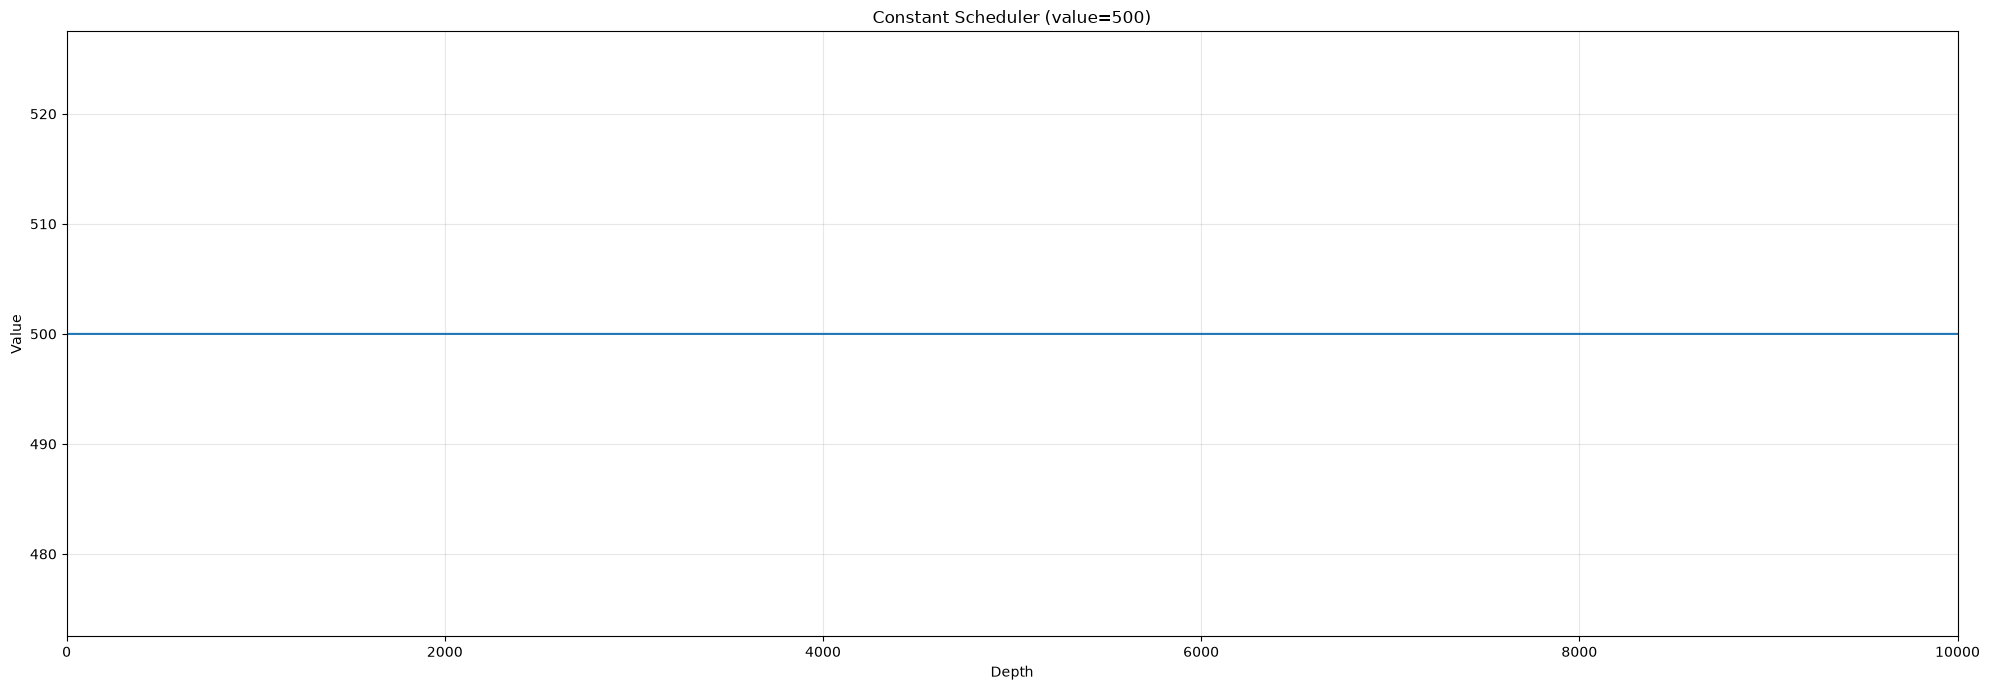

In [5]:
# plot the scheduler
fig, ax = plt.subplots(figsize=(20, 7))
plot_scheduler(ax, scheduler)
fig.tight_layout()
plt.show()

## Conclusions

This playground provides an empirical view of how a `ConstantScheduler` maps depth to a fixed value. Regardless of the depth at which it is evaluated, the scheduler preserves the value with which it was configured.

Examined in isolation, the module exhibits its intended behavior: it implements a depth-independent scheduling strategy in which the scheduled value remains constant across depth.